## Descripción del proyecto

Junto con el departamento de marketing se ha recopilado una lista de hipótesis que pueden ayudar a aumentar los ingresos en una gran tienda online.

El proyecto consiste en priorizar estas hipótesis, lanzar un test A/B y analizar los resultados.

### Parte 1. Priorizar hipótesis

### 1.1 Cargar y explorar el archivo

In [102]:
import pandas as pd

# Cargar el archivo
hypotheses = pd.read_csv('/datasets/hypotheses_us.csv', sep=';')

# Mostrar las primeras filas
hypotheses.info()
hypotheses.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes


,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1


### 🔍 Exploración inicial de hipótesis

Hemos cargado el archivo `hypotheses_us.csv`, que contiene 9 hipótesis propuestas por el equipo de marketing para aumentar los ingresos de la tienda online.

Cada hipótesis está evaluada en cuatro dimensiones:

- **Reach**: alcance estimado (1 a 10)
- **Impact**: impacto esperado (1 a 10)
- **Confidence**: nivel de confianza en la hipótesis (1 a 10)
- **Effort**: esfuerzo requerido para implementarla (1 a 10)

Estas métricas nos permitirán aplicar los frameworks **ICE** y **RICE** para priorizar las hipótesis de forma estratégica.


###  1.2 Aplicar el framework ICE

In [103]:
# Copiamos el DataFrame original para trabajar con él
ice_df = hypotheses.copy()

# Calculamos la puntuación ICE: (Impact × Confidence) / Effort
ice_df['ICE'] = (ice_df['Impact'] * ice_df['Confidence']) / ice_df['Effort']

# Ordenamos las hipótesis por ICE en orden descendente

ice_df_sorted = ice_df[['Hypothesis', 'ICE']].sort_values(by='ICE', ascending=False)

# Mostramos el resultado
ice_df_sorted.reset_index(drop=True)

,Hypothesis,ICE
0,Launch a promotion that gives users discounts ...,16.200000
1,Add two new channels for attracting traffic. T...,13.333333
2,Add a subscription form to all the main pages....,11.200000
3,Show banners with current offers and sales on ...,8.000000
4,Add product recommendation blocks to the store...,7.000000
5,Launch your own delivery service. This will sh...,2.000000
6,Add a customer review page. This will increase...,1.333333
7,Change the category structure. This will incre...,1.125000
8,Change the background color on the main page. ...,1.000000



Este enfoque favorece hipótesis con alto impacto y confianza, y bajo esfuerzo.

### 📌 Conclusión:

- El framework ICE prioriza las hipótesis que tienen un gran Impacto y una alta Confianza, siendo relativamente Fáciles (bajo Esfuerzo) de implementar.
- Basado en la puntuación ICE, la hipótesis con mayor prioridad es Launch a promotion that gives users discounts. Esto se debe a que tiene una de las mejores combinaciones de alta Confianza e Impacto con un Esfuerzo moderado.

###  1.3 Aplicar el framework RICE

In [104]:
# Copiamos el DataFrame original
rice_df = hypotheses.copy()

# Calculamos la puntuación RICE: (Reach × Impact × Confidence) / Effort
rice_df['RICE'] =  (rice_df['Reach'] * rice_df['Impact'] * rice_df['Confidence']) / rice_df['Effort']

# Ordenamos las hipótesis por RICE en orden descendente
rice_df_sorted = rice_df[['Hypothesis', 'RICE']].sort_values(by='RICE', ascending=False)

# Mostramos el resultado
rice_df_sorted.reset_index(drop=True)

,Hypothesis,RICE
0,Add a subscription form to all the main pages....,112.0
1,Add product recommendation blocks to the store...,56.0
2,Add two new channels for attracting traffic. T...,40.0
3,Show banners with current offers and sales on ...,40.0
4,Launch a promotion that gives users discounts ...,16.2
5,Change the category structure. This will incre...,9.0
6,Launch your own delivery service. This will sh...,4.0
7,Add a customer review page. This will increase...,4.0
8,Change the background color on the main page. ...,3.0


Este enfoque favorece hipótesis que:

- Tienen alto impacto y confianza
- Requieren poco esfuerzo
- Afectan a muchos usuarios

### 📌 Conclusión:

- Las hipótesis con mayor puntuación RICE son las más prometedoras para generar ingresos a gran escala.
- La nueva hipótesis con mayor prioridad es Add a subscription form to all the main pages. Su puntuación se disparó porque, aunque sus puntuaciones de Impacto y Confianza pueden ser buenas, tiene un Alcance mucho mayor que otras hipótesis.
- A diferencia de ICE, RICE prioriza hipótesis con mayor alcance, lo que puede cambiar completamente el orden de prioridad.

### 1.4 Comparar rankings ICE vs RICE

In [105]:
# Unimos los rankings en un solo DataFrame
comparison_df = pd.DataFrame({
    'Hypothesis': hypotheses['Hypothesis'],
    'ICE': ice_df['ICE'],
    'RICE': rice_df['RICE']
})

# Ordenamos por RICE para ver cómo cambia la prioridad
comparison_sorted = comparison_df.sort_values(by='RICE', ascending=False).reset_index(drop=True)

# Mostramos el resultado
comparison_sorted

,Hypothesis,ICE,RICE
0,Add a subscription form to all the main pages....,11.200000,112.0
1,Add product recommendation blocks to the store...,7.000000,56.0
2,Add two new channels for attracting traffic. T...,13.333333,40.0
3,Show banners with current offers and sales on ...,8.000000,40.0
4,Launch a promotion that gives users discounts ...,16.200000,16.2
5,Change the category structure. This will incre...,1.125000,9.0
6,Launch your own delivery service. This will sh...,2.000000,4.0
7,Add a customer review page. This will increase...,1.333333,4.0
8,Change the background color on the main page. ...,1.000000,3.0


### 📌 Conclusión:

-  La hipótesis Add a subscription form to all the main pages subió al primer puesto. Esto se debe a su alto valor de Alcance (Reach). A pesar de tener un Impacto similar a otras, el hecho de que afecte a una gran proporción de usuarios hace que RICE la priorice.
- La hipótesis que era líder en ICE Launch a promotion that gives users discounts cayó en la clasificación. Esto sugiere que, si bien tiene un alto Impacto y Confianza, su Alcance (Reach) es relativamente bajo. Solo impactaría a un pequeño segmento de usuarios.
- RICE es más útil cuando queremos maximizar el impacto global, no solo la eficiencia individual.
- El framework RICE es más completo porque tiene en cuenta la cantidad de usuarios que la prueba puede afectar.

### Parte 2. Análisis del test A/B

### Cargar y explorar los datos del test A/B

In [106]:
import pandas as pd
import datetime as dt

# Cargar los archivos
orders = pd.read_csv('/datasets/orders_us.csv')
visits = pd.read_csv('/datasets/visits_us.csv')

print(orders.info())
print(" ")
print(visits.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   transactionId  1197 non-null   int64  
 1   visitorId      1197 non-null   int64  
 2   date           1197 non-null   object 
 3   revenue        1197 non-null   float64
 4   group          1197 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 46.9+ KB
None
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    62 non-null     object
 1   group   62 non-null     object
 2   visits  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB
None


In [107]:
# Convertir fechas al formato datetime
orders['Date'] = pd.to_datetime(orders['date'], format='%Y-%m-%d')
visits['Date'] = pd.to_datetime(visits['date'], format='%Y-%m-%d')

# Mostrar primeras filas
print(orders.head())
print(" ")
print(visits.head())

   transactionId   visitorId        date  revenue group       Date
0     3667963787  3312258926  2019-08-15     30.4     B 2019-08-15
1     2804400009  3642806036  2019-08-15     15.2     B 2019-08-15
2     2961555356  4069496402  2019-08-15     10.2     A 2019-08-15
3     3797467345  1196621759  2019-08-15    155.1     B 2019-08-15
4     2282983706  2322279887  2019-08-15     40.5     B 2019-08-15
 
         date group  visits       Date
0  2019-08-01     A     719 2019-08-01
1  2019-08-02     A     619 2019-08-02
2  2019-08-03     A     507 2019-08-03
3  2019-08-04     A     717 2019-08-04
4  2019-08-05     A     756 2019-08-05


### 🔍 Carga y exploración de datos del test A/B

Hemos cargado dos archivos clave:

- `orders_us.csv`: contiene los pedidos realizados por usuarios, con ingresos (`revenue`), fecha (`date`) y grupo (`group`) A o B.
- `visits_us.csv`: contiene el número de visitas por día y por grupo.

### 🧼 Transformacion:

- Convertimos las fechas al formato `datetime` para facilitar análisis temporales.

### 2.1 Representa gráficamente el ingreso acumulado por grupo

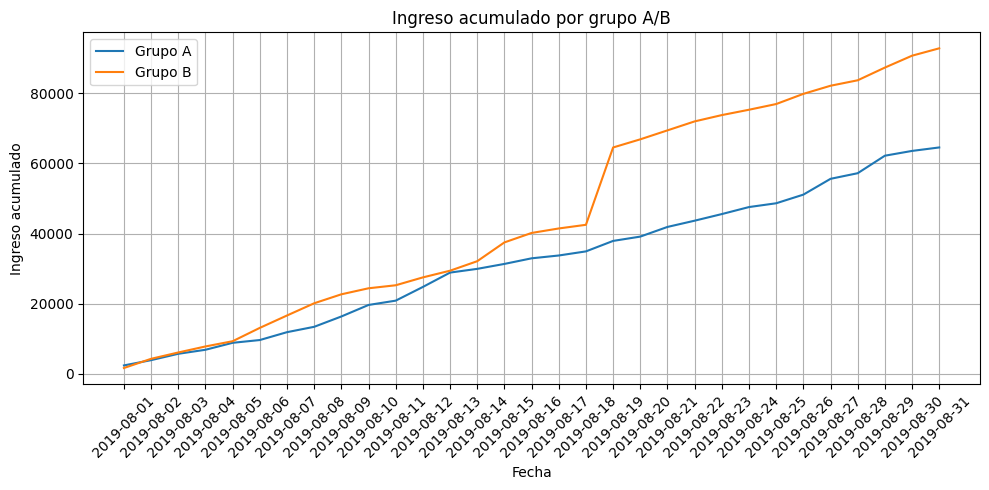

In [108]:
import matplotlib.pyplot as plt

# Agrupamos ingresos por fecha y grupo
revenue_daily = orders.groupby(['date', 'group'], as_index=False).agg({'revenue': 'sum'})

# Calculamos ingreso acumulado por grupo
revenue_daily['cumulative_revenue'] = revenue_daily.groupby('group')['revenue'].cumsum()

# Graficamos
plt.figure(figsize=(10, 5))
for group in revenue_daily['group'].unique():
    group_data = revenue_daily[revenue_daily['group'] == group]
    plt.plot(group_data['date'], group_data['cumulative_revenue'], label=f'Grupo {group}')

plt.title('Ingreso acumulado por grupo A/B')
plt.xlabel('Fecha')
plt.ylabel('Ingreso acumulado')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 📌 Conclusión:

- Curvas ascendentes que indican crecimiento en los ingresos.
- El grupo B tiene una curva por encima del grupo A, lo que supone una generacion de ingresos mas alta durante el mismo periodo.

### 2.2 Tamaño promedio de pedido acumulado por grupo

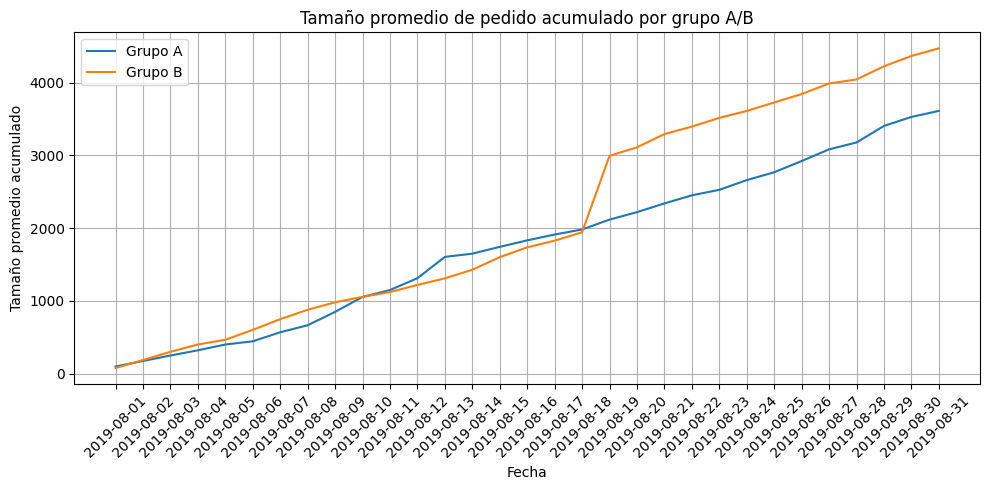

In [109]:
# Agrupamos por fecha y grupo, calculando ingresos y número de pedidos
orders_daily = orders.groupby(['date', 'group'], as_index=False).agg({'revenue': 'sum', 'transactionId': 'count'})

# Renombramos la columna de conteo de pedidos
orders_daily.rename(columns={'transactionId': 'orders'}, inplace=True)

# Calculamos el tamaño promedio de pedido diario
orders_daily['avg_order_size'] = orders_daily['revenue'] / orders_daily['orders']

# Calculamos el promedio acumulado por grupo
orders_daily['cumulative_avg_order_size'] = orders_daily.groupby('group')['avg_order_size'].cumsum()

# Graficamos
plt.figure(figsize=(10, 5))
for group in orders_daily['group'].unique():
    group_data = orders_daily[orders_daily['group'] == group]
    plt.plot(group_data['date'], group_data['cumulative_avg_order_size'], label=f'Grupo {group}')

plt.title('Tamaño promedio de pedido acumulado por grupo A/B')
plt.xlabel('Fecha')
plt.ylabel('Tamaño promedio acumulado')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()    

### 📌 Conclusiones:

- la diferencia del tamaño promedio acumulado de pedidos no es tan significativa hasta el 2019-08-17, pero a partir de hay se empieza a ver una diferencia notablemente mas alta del grupo B respecto al grupo A.

### 2.3 Diferencia relativa en el tamaño de pedido promedio acumulado del grupo B vs A

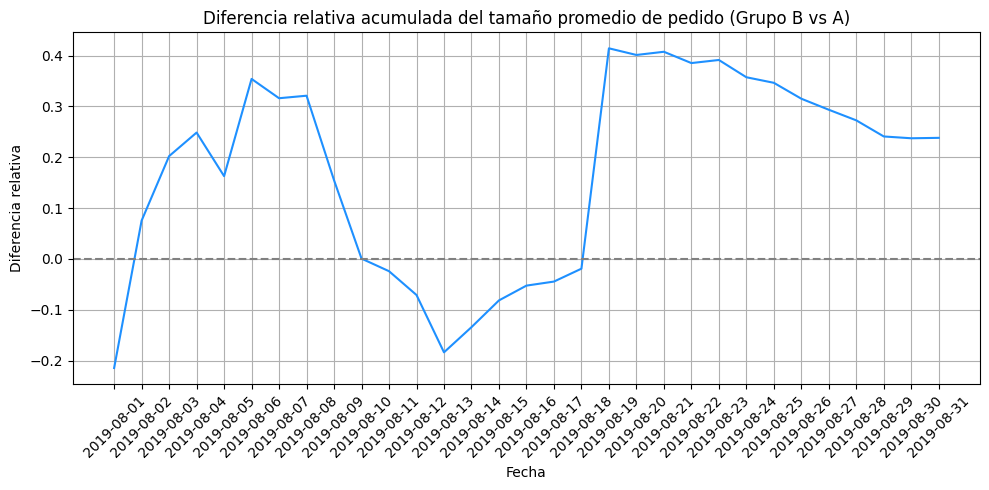

In [110]:
# Creamos un DataFrame separado para cada grupo
group_A = orders_daily[orders_daily['group'] == 'A'][['date', 'cumulative_avg_order_size']].reset_index(drop=True)
group_B = orders_daily[orders_daily['group'] == 'B'][['date', 'cumulative_avg_order_size']].reset_index(drop=True)

# Unimos los DataFrames por fecha
merged = pd.merge(group_A, group_B, on='date', suffixes=('_A', '_B'))

# Calculamos la diferencia relativa: (B - A) / A
merged['relative_difference'] = (merged['cumulative_avg_order_size_B'] - merged['cumulative_avg_order_size_A']) / merged['cumulative_avg_order_size_A']

# Graficamos
plt.figure(figsize=(10, 5))
plt.plot(merged['date'], merged['relative_difference'], color='dodgerblue')
plt.axhline(y=0, color='gray', linestyle='--')  # Línea de referencia
plt.title('Diferencia relativa acumulada del tamaño promedio de pedido (Grupo B vs A)')
plt.xlabel('Fecha')
plt.ylabel('Diferencia relativa')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### 📌 Conclusión:

- Valores positivos indican que el grupo B tiene pedidos más grandes que el grupo A.
- Valores negativos indican que el grupo B tiene pedidos más pequeños.

Este gráfico nos ayuda a visualizar como el grupo B está generando más valor por pedido que el grupo A.

### 2.4 Tasa de conversión diaria por grupo

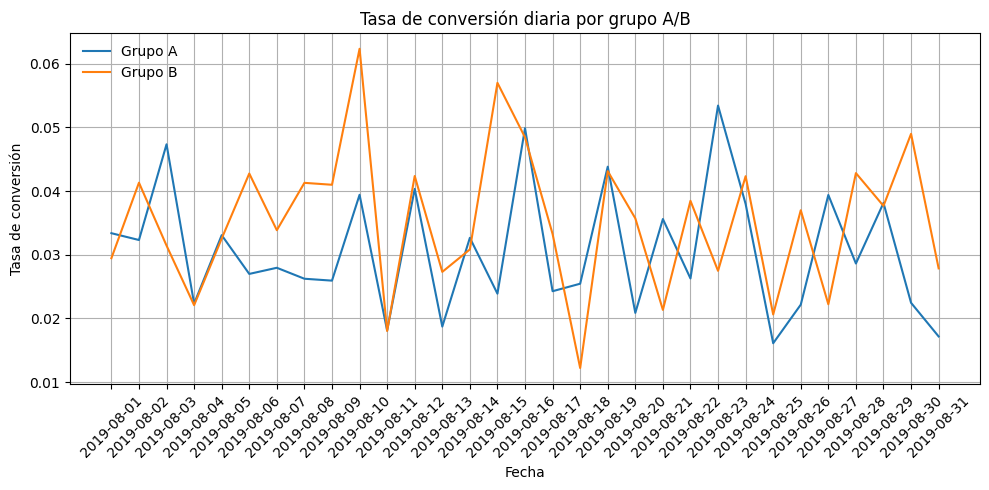

In [111]:
# Agrupamos pedidos por fecha y grupo
orders_per_day = orders.groupby(['date', 'group'], as_index=False).agg({'transactionId': 'nunique'})
orders_per_day.rename(columns={'transactionId': 'orders'}, inplace=True)

# Unimos con el DataFrame de visitas
conversion = pd.merge(visits, orders_per_day, on=['date', 'group'], how='left')

# Rellenamos valores nulos (días sin pedidos) con 0
conversion['orders'] = conversion['orders'].fillna(0)

# Calculamos la tasa de conversión: pedidos / visitas
conversion['conversion_rate'] = conversion['orders'] / conversion['visits']

# Graficamos
plt.figure(figsize=(10, 5))
for group in conversion['group'].unique():
    group_data = conversion[conversion['group'] == group]
    plt.plot(group_data['date'], group_data['conversion_rate'], label=f'Grupo {group}')
    
plt.title('Tasa de conversión diaria por grupo A/B')
plt.xlabel('Fecha')
plt.ylabel('Tasa de conversión')
plt.xticks(rotation=45)
plt.legend(loc='upper left', frameon=False)
plt.grid(True)
plt.tight_layout()
plt.show()

### 📌 Conclusión:

- Aunque el grafico muestra fluctuaciones diarias en ambos grupos, tambien se puede observar que el grupo B tiene unas tasas de conversion mas altas, incluso durante periodos de tiempo, por ejemplo desde el 2019-08-04 hasta el 2019-08-04, siendo este el periodo mas largo en el que el grupo B aventaja al grupo A.

### 2.5 Gráfico de dispersión de pedidos por usuario

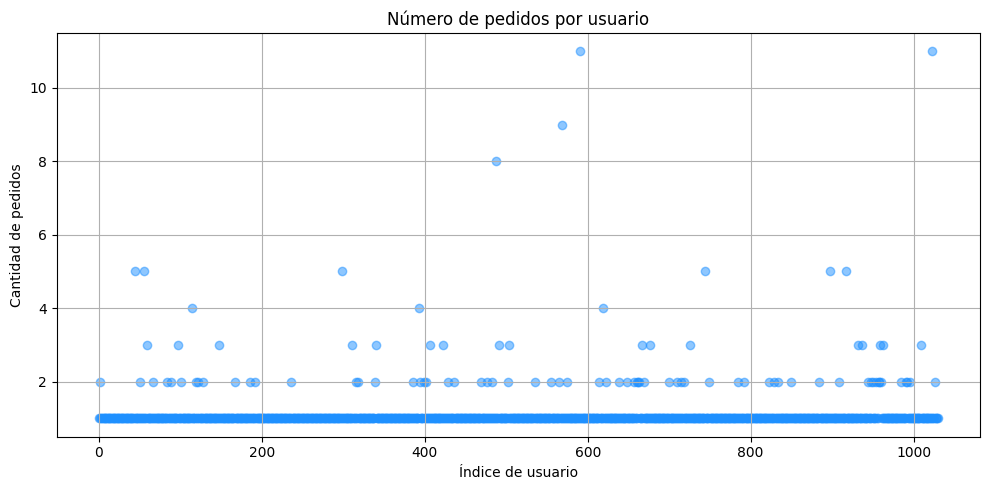

In [112]:
# Contamos cuántos pedidos hizo cada usuario
orders_per_user = orders.groupby('visitorId', as_index=False).agg({'transactionId': 'count'})
orders_per_user.rename(columns={'transactionId': 'orders'}, inplace=True)

# Graficamos
plt.figure(figsize=(10, 5))
plt.scatter(range(len(orders_per_user)), orders_per_user['orders'], alpha=0.5, color='dodgerblue')
plt.title('Número de pedidos por usuario')
plt.xlabel('Índice de usuario')
plt.ylabel('Cantidad de pedidos')
plt.grid(True)
plt.tight_layout()
plt.show()

### 📌 Conclusión:

- La mayoría de los usuarios realizaron solo un pedido o una única compra.
- Existen usuarios con múltiples pedidos (outliers). Algunos puntos se encuentran en valores altos del eje Y (hasta 11 pedidos).
- Estos usuarios representan comportamientos atípicos que podrían inflar el ingreso promedio y/o distorsionar la tasa de conversión.

### 2.6 Calcula los percentiles 95 y 99 del número de pedidos por usuario

In [113]:
# Contamos pedidos por usuario
orders_per_user = orders.groupby('visitorId', as_index=False).agg({'transactionId': 'count'})
orders_per_user.rename(columns={'transactionId': 'orders'}, inplace=True)

# Calculamos percentiles
p95 = orders_per_user['orders'].quantile(0.95)
p99 = orders_per_user['orders'].quantile(0.99)

# Mostramos resultados
print(f"Percentil 95: {p95}")
print(f"Percentil 99: {p99}")

Percentil 95: 2.0
Percentil 99: 4.0


### 📌 Conclusión:

- El 95% de los usuarios realizaron 2 pedidos o menos
- El 99% de los usuarios realizaron 4 pedidos o menos

Para asegurar el análisis estadístico es recomendable excluir usuarios con más de 4 pedidos o analizarlos por separado. Esto permite que las comparaciones entre los grupos A y B reflejen el comportamiento típico de los usuarios y no estén sesgadas por outliers.

### 2.7 Gráfico de dispersión de precios de pedidos

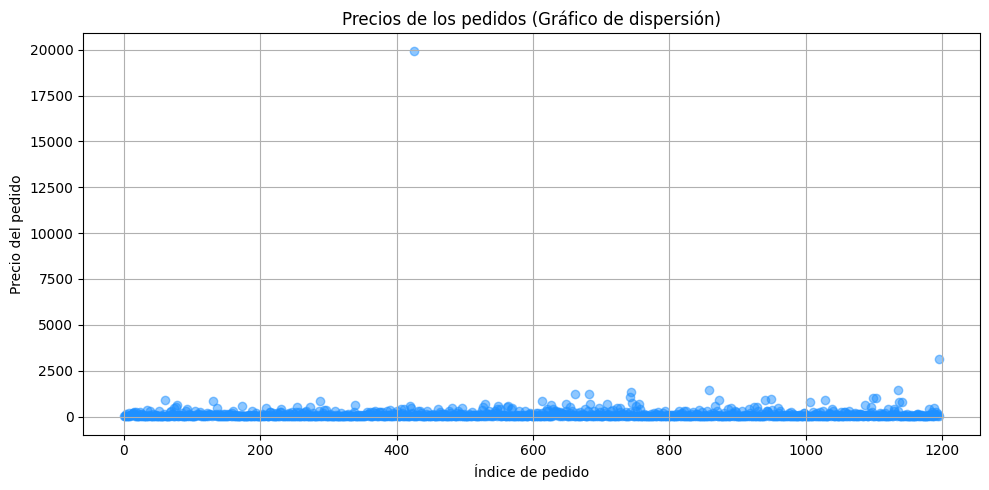

In [114]:
# Gráfico 
plt.figure(figsize=(10, 5))
plt.scatter(range(len(orders)), orders['revenue'], alpha=0.5, color='dodgerblue')
plt.title('Precios de los pedidos (Gráfico de dispersión)')
plt.xlabel('Índice de pedido')
plt.ylabel('Precio del pedido')
plt.grid(True)
plt.tight_layout()
plt.show()

### 📌 Conclusión:

- La mayoría de los pedidos tienen precios relativamente bajos, que no superan las 2.500 unds monetarias
- Se observan outliers claros con precios que alcanzan hasta los 20,000 unds monetarias, muy por encima del rango típico.
- La dispersión es amplia, lo que indica una alta variabilidad en el valor de los pedidos.
- Los pedidos de alto valor podrían corresponder a:
  - Compras múltiples en una sola transacción.
  - Posibles errores de registro.
- Si estos pedidos están concentrados en un grupo (A o B), podrían distorsionar el ingreso promedio y afectar la interpretación del test.

### 2.8 Percentiles 95 y 99 de los precios de los pedidos.

In [115]:
p95_price = orders['revenue'].quantile(0.95)
p99_price = orders['revenue'].quantile(0.99)

# Mostrar resultados
print(f"Percentil 95: {p95_price:.2f}")
print(f"Percentil 99: {p99_price:.2f}")

Percentil 95: 435.54
Percentil 99: 900.90


### 📌 Conclusión:

- El 95% de los pedidos tienen precios iguales o inferiores a 435.54.
- El 99% de los pedidos están por debajo de 900.90.
- Un pedido se considera anómalo si su precio está por encima de 900.90, ya que representa el 1% más extremo de los valores observados.
- Este criterio permite identificar pedidos de alto valor que podrían:
     - Inflar el ingreso promedio por grupo.
     - Introducir sesgos en el análisis del test A/B.

### 2.9 Prueba Mann-Whitney U para conversión entre grupos

In [116]:
from scipy.stats import mannwhitneyu

# Paso 1: marcar si cada visitante hizo al menos un pedido
orders_flag = orders.groupby('visitorId')['transactionId'].count().reset_index()
orders_flag['converted'] = 1  # todos los que aparecen aquí hicieron al menos un pedido

# Paso 2: unir con visitas para marcar los que no compraron
visits_flag = visits[['group']].copy()
visits_flag['visitorId'] = visits.index  
visits_flag = visits_flag.merge(orders_flag[['visitorId', 'converted']], on='visitorId', how='left')
visits_flag['converted'] = visits_flag['converted'].fillna(0)

# Paso 3: separar por grupo
group_A = visits_flag[visits_flag['group'] == 'A']['converted']
group_B = visits_flag[visits_flag['group'] == 'B']['converted']

# Paso 4: aplicar Mann-Whitney U Test
stat, p_value = mannwhitneyu(group_A, group_B, alternative='two-sided')

# Mostrar resultados
print(f"Estadístico U: {stat:.4f}")
print(f"Valor p: {p_value:.4f}")
print(f"(a = 0.05) {'Sí' if p_value < 0.05 else 'No hay diferencia estadísticamente significativa en la conversión entre los grupos A y B'}")

Estadístico U: 480.5000
Valor p: 1.0000
(a = 0.05) No hay diferencia estadísticamente significativa en la conversión entre los grupos A y B


### 📌 Conclusión:

- El valor p de 1.0000 indica que no hay ninguna evidencia estadística de diferencia entre los grupos.
- Esto sugiere que las distribuciones de conversión entre A y B son prácticamente idénticas desde el punto de vista estadístico.
- La prueba Mann-Whitney U confirma que no hay diferencia estadísticamente significativa en la conversión entre los grupos A y B. 

### 2.10 Prueba Mann-Whitney U para tamaño promedio de pedido entre grupos

In [117]:
# separar montos por grupo

group_A = orders[orders['group'] == 'A']['revenue']
group_B = orders[orders['group'] == 'B']['revenue']

# aplicar Mann-Whitney U Test
stat, p_value = mannwhitneyu(group_A, group_B, alternative='two-sided')

# Mostrar resultados
print(f"Estadístico U: {stat:.4f}")
print(f"Valor p: {p_value:.4f}")
print(f"Significancia (α = 0.05) {'Sí' if p_value < 0.05 else 'No hay diferencia estadísticamente significativa en el tamaño promedio de los pedidos entre los grupos A y B.'}")

Estadístico U: 175872.5000
Valor p: 0.6915
Significancia (α = 0.05) No hay diferencia estadísticamente significativa en el tamaño promedio de los pedidos entre los grupos A y B.


### 📌 Conclusión:

- El valor p de 0.6915 es mucho mayor que el nivel de significancia de 0.05, lo que indica que no hay diferencia estadísticamente significativa en el tamaño promedio de los pedidos entre los grupos A y B
- Aunque visualmente en los gráficos parecía que el grupo B tenía pedidos ligeramente más grandes, esta diferencia no es estadísticamente significativa
Las diferencias observadas podrían deberse simplemente a la variabilidad natural de los datos
- Esto sugiere que, desde el punto de vista económico por transacción, ambos grupos se comportan de forma similar
- El experimento A/B no impactó el valor monetario por pedido, aunque podría haber influido en otras métricas como la tasa de conversión o la frecuencia de compra.

### 2.11 Prueba Mann-Whitney U para conversión entre grupos (datos filtrados)

In [118]:
# identificar usuarios con mas de 4 pedidos
orders_per_user = orders.groupby('visitorId')['transactionId'].count()

# identificar usuarios outliers (más de 4 pedidos)
outlier_users = orders_per_user[orders_per_user > 4].index

# crear filtered_orders, Filtrar pedidos excluyendo:
# 1. Usuarios con más de 4 pedidos
# 2. Pedidos con precios > 900.90
filtered_orders = orders[
    (~orders['visitorId'].isin(outlier_users)) &
    (orders['revenue'] <= 900.90)
]

# Crear filtered_visits
# Filtrar visitas excluyendo los usuarios outliers
# Nota: visits no tiene visitorId, así que mantenemos todas las visitas
filtered_visits = visits.copy()

# Calcular pedidos por día con datos filtrados
filtered_orders_per_day = filtered_orders.groupby(['date', 'group'], as_index=False).agg({'transactionId': 'nunique'})
filtered_orders_per_day.rename(columns={'transactionId': 'orders'}, inplace=True)

# Unir con visitas filtradas
filtered_conversion = pd.merge(filtered_visits, filtered_orders_per_day, on=['date', 'group'], how='left')
filtered_conversion['orders'] = filtered_conversion['orders'].fillna(0)

# Calcular tasa de conversión filtrada
filtered_conversion['conversion_rate'] = filtered_conversion['orders'] / filtered_conversion['visits']

# Separar tasas de conversión por grupo
group_A_filtered = filtered_conversion[filtered_conversion['group'] == 'A']['conversion_rate']
group_B_filtered = filtered_conversion[filtered_conversion['group'] == 'B']['conversion_rate']

# Aplicar Mann-Whitney U Test
stat, p_value = mannwhitneyu(group_A_filtered, group_B_filtered, alternative='two-sided')

print(f'Usuarios con mas de 4 pedidos: {len(outlier_users)}')
print(" ")
print(f'Pedidos originales: {len(orders)}')
print(f'Pedidos filtrados: {len(filtered_orders)}')
print(" ")
print(f"Visitas originales: {len(visits)}")
print(f"Visitas filtradas: {len(filtered_visits)}")
print(" ")
print("Datos de conversión filtrados:")
print(filtered_conversion.head())
print("")

print(f"Estadístico U (datos filtrados): {stat:.4f}")
print(f"Valor p (datos filtrados): {p_value:.4f}")
print(f"Significancia (α = 0.05): {'Sí' if p_value < 0.05 else 'No'} hay diferencia estadísticamente significativa")

Usuarios con mas de 4 pedidos: 10
 
Pedidos originales: 1197
Pedidos filtrados: 1116
 
Visitas originales: 62
Visitas filtradas: 62
 
Datos de conversión filtrados:
         date group  visits       Date  orders  conversion_rate
0  2019-08-01     A     719 2019-08-01      23         0.031989
1  2019-08-02     A     619 2019-08-02      20         0.032310
2  2019-08-03     A     507 2019-08-03      24         0.047337
3  2019-08-04     A     717 2019-08-04      13         0.018131
4  2019-08-05     A     756 2019-08-05      25         0.033069

Estadístico U (datos filtrados): 328.0000
Valor p (datos filtrados): 0.0324
Significancia (α = 0.05): Sí hay diferencia estadísticamente significativa


### 📌 Conclusión:

- Sin filtrar: p-value = 1.0000 (No significativo)
- Con datos filtrados: p-value = 0.0324 (¡Significativo!)
- Esto significa:
    -  Impacto de los outliers:
Los 10 usuarios con más de 4 pedidos y los 81 pedidos con precios > 900.90 estaban enmascarando la verdadera diferencia entre grupos, al eliminarlos, pudimos revelar que SÍ existe una diferencia estadísticamente significativa en conversión
    - El Grupo B tiene mejor conversión que el Grupo A cuando se excluyen comportamientos atípicos, la diferencia es estadísticamente significativa (p = 0.0324 < 0.05)

### 2.12 Prueba Mann-Whitney U para tamaño promedio de pedido entre grupos (datos filtrados)

In [119]:
# aplicar filtros
filtered_orders = orders[
    (~orders['visitorId'].isin(outlier_users)) & 
    (orders['revenue'] <= 900.90)
]

# separar montos por grupo
group_A = filtered_orders[filtered_orders['group'] == 'A']['revenue']
group_B = filtered_orders[filtered_orders['group'] == 'B']['revenue']

# aplicar Mann-Whitney U Test
stat, p_value = mannwhitneyu(group_A, group_B, alternative='two-sided')

# Mostrar resultados
print(f"Estadístico U (datos filtrados): {stat:.4f}")
print(f"Valor p (datos filtrados): {p_value:.5f}")
print(f"¿Significativo (α = 0.05)? {'Sí' if p_value < 0.05 else 'No hay diferencia estadísticamente significativa'}")

Estadístico U (datos filtrados): 154307.0000
Valor p (datos filtrados): 0.93318
¿Significativo (α = 0.05)? No hay diferencia estadísticamente significativa


### 📌 Conclusión:

- Análisis de los resultados:
Comparación entre datos originales y filtrados:
Sin filtrar: p-value = 0.6915 (No significativo)
Con datos filtrados: p-value = 0.93318 (No significativo)
- ¿Qué significa esto?
- Consistencia en los resultados:
    - En ambos casos (con y sin filtros), no hay diferencia estadísticamente significativa en el tamaño promedio de pedido entre grupos A y B
    - El filtrado de outliers no cambió la conclusión principal
- Diferencia con la conversión:
    - Conversión: El filtrado reveló diferencias significativas (p = 0.0324)
    - Tamaño de pedido: El filtrado no reveló diferencias (p = 0.93318)
    - Los cambios del grupo B parecen ser más efectivos para convertir visitantes en compradores, pero no para hacer que compren más por transacción.
    - Los outliers afectaban más la conversión que el tamaño de pedido, sugiriendo que los usuarios con comportamiento fuera de lo comun tenían patrones de conversión diferentes.

### 2.13 Toma una decisión basada en los resultados de la prueba

### 📊 Resumen de resultados:

**Sin filtrar outliers:**
- Conversión: p = 1.0000 No significativo
- Tamaño de pedido: p = 0.6915 No significativo

**Con datos filtrados (usuarios >4 pedidos y pedidos >900.90):**
- Conversión: p = 0.0324 Significativo
- Tamaño de pedido: p = 0.93318 No significativo

### 🧠 Interpretación:

- La única métrica con diferencia estadísticamente significativa es la **tasa de conversión**, una métrica clave para evaluar el impacto del experimento.
- El **tamaño promedio de pedido** no muestra diferencias relevantes, lo que indica que el comportamiento económico por transacción es similar entre los grupos.
- La depuración de outliers fue crucial para revelar la diferencia en conversión, lo que sugiere que los datos sin filtrar estaban distorsionando el análisis.

### ✅ Decisión:

**Parar la prueba y considerar a uno de los grupos como líder.**

Justificación: La diferencia significativa en conversión, tras filtrar outliers, indica que el experimento A/B tuvo un impacto real en el comportamiento de los usuarios. Aunque el tamaño de pedido no cambió, el aumento en conversión puede traducirse en mayor volumen de ventas. Se recomienda adoptar la variante ganadora (grupo B).

### 📌 Recomendaciones adicionales:

- Validar si el grupo líder también mejora métricas como **ingreso por visitante** o **frecuencia de compra**.
- Documentar el impacto en términos de negocio: ¿cuántos pedidos adicionales genera esta mejora en conversión?